## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

## 2. Load Data

In [2]:
df = pd.read_csv(r'transaction_data.csv')

In [3]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data Cleaning

### 3.1 Kiểm tra Missing Values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516384 entries, 0 to 516383
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   516384 non-null  object 
 1   stock_code    516384 non-null  object 
 2   description   514945 non-null  object 
 3   quantity      516384 non-null  int64  
 4   invoice_date  516384 non-null  object 
 5   unit_price    516384 non-null  float64
 6   cust_id       389168 non-null  float64
 7   country       516384 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 31.5+ MB


In [5]:
df.describe()

,quantity,unit_price,cust_id
count,516384.000000,516384.000000,389168.000000
mean,9.586116,4.579709,15287.024473
std,156.331122,94.287694,1712.959478
min,-74215.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13952.000000
50%,3.000000,2.080000,15154.000000
75%,10.000000,4.130000,16788.000000
max,74215.000000,38970.000000,18287.000000


In [6]:
df.isna().sum()

invoice_num          0
stock_code           0
description       1439
quantity             0
invoice_date         0
unit_price           0
cust_id         127216
country              0
dtype: int64

### 3.2 Xóa tất cả các hàng chứa Missing Values

In [7]:
null_stock_code = df[df['description'].isna()]['stock_code'].drop_duplicates()
null_stock_code

622        22139
1970       21134
1971       22145
1972       37509
1987      85226A
           ...  
511451     22810
514205     21116
514287    47503A
514651     21927
516189     22947
Name: stock_code, Length: 951, dtype: object

In [8]:
#lấy description của các stock_code bị null
null_stock_code_df = df[df['stock_code'].isin(null_stock_code)].dropna().drop_duplicates(subset='stock_code')
null_stock_code_df = null_stock_code_df[['stock_code', 'description']]
null_stock_code_df

,stock_code,description
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.
7,22633,HAND WARMER UNION JACK
8,22632,HAND WARMER RED POLKA DOT
...,...,...
404128,23579,SNACK TRAY I LOVE LONDON
406162,23702,High Resolution Image
449426,79161A,ST GEORGE SET OF 10 PARTY LIGHTS
473228,35598A,DUSTY PINK CHRISTMAS TREE 60CM


In [9]:
null_stock_code_df = null_stock_code_df.rename(
    columns={'description': 'description_2'}
)

In [10]:
null_stock_code_df.head()

,stock_code,description_2
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.
7,22633,HAND WARMER UNION JACK
8,22632,HAND WARMER RED POLKA DOT


In [11]:
# merge thông tin description_2 vào bảng df:
df = pd.merge(
    left = df,
    right = null_stock_code_df,
    how = 'left',
    on = 'stock_code'
)

In [12]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,description_2
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.


In [13]:
df[df['description'].isna()]

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,description_2
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,RETROSPOT TEA SET CERAMIC 11 PC
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,NaN
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,CHRISTMAS CRAFT HEART STOCKING
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,NEW ENGLAND MUG W GIFT BOX
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,NaN
...,...,...,...,...,...,...,...,...,...
511451,579500,22810,NaN,33,2011-11-29 16:14:00,0.0,NaN,United Kingdom,SET OF 6 T-LIGHTS SNOWMEN
514205,579688,21116,NaN,-33,2011-11-30 13:51:00,0.0,NaN,United Kingdom,OWL DOORSTOP
514287,579691,47503A,NaN,-5,2011-11-30 14:05:00,0.0,NaN,United Kingdom,ASS FLORAL PRINT MULTI SCREWDRIVER
514651,579738,21927,NaN,8,2011-11-30 14:26:00,0.0,NaN,United Kingdom,BLUE/CREAM STRIPE CUSHION COVER


In [14]:
# lọc ra các stock_code bị null description và gán lại từ cột description_2:
df.loc[ df['description'].isna(), 'description' ] = df['description_2']

In [15]:
# Fill những description vẫn còn bị null giá trị "unknown":
df['description'] = df['description'].fillna('unknown')

In [16]:
# Bỏ cột description_2:
df= df.drop(columns='description_2')

In [17]:
# Bỏ giá trị bị null trong df:
df =  df.dropna()

In [18]:
df.isna().sum()

invoice_num     0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
cust_id         0
country         0
dtype: int64

### 3.3 Chuyển đổi kiểu dữ liệu

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389168 entries, 0 to 516383
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   389168 non-null  object 
 1   stock_code    389168 non-null  object 
 2   description   389168 non-null  object 
 3   quantity      389168 non-null  int64  
 4   invoice_date  389168 non-null  object 
 5   unit_price    389168 non-null  float64
 6   cust_id       389168 non-null  float64
 7   country       389168 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 26.7+ MB


In [20]:
# correcting datatypes:
df['cust_id'] = df['cust_id'].astype('str')
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [21]:
df.describe()

,quantity,invoice_date,unit_price
count,389168.000000,389168,389168.000000
mean,12.084889,2011-07-03 23:25:50.435750400,3.488779
min,-74215.000000,2010-12-01 08:26:00,0.000000
25%,2.000000,2011-04-01 11:34:00,1.250000
50%,5.000000,2011-07-20 14:06:00,1.950000
75%,12.000000,2011-10-12 12:47:00,3.750000
max,74215.000000,2011-11-30 17:42:00,38970.000000
std,175.692602,NaN,70.796324


### 3.4 Tạo các đặc trưng thời gian

In [22]:
# xtracting time infomation from 'invoice_date' column
df['month'] = df['invoice_date'].dt.month
df['day'] = df['invoice_date'].dt.day
df['hour'] = df['invoice_date'].dt.hour
df['week_days'] = df['invoice_date'].dt.strftime('%a')
df['year_month'] = df['invoice_date'].dt.strftime('%Y-%m')


### 3.5 Chuyển đổi các giá trị số âm

In [23]:
# convert negative numbers
df['quantity'] = df['quantity'].abs()
df['unit_price'] = df['unit_price'].abs()

### 3.4 Tính toán doanh thu

In [103]:
# Add column Amount
df['Amount'] = df['quantity'] * df['unit_price']

## 4. Exploratory Data Analysis (EDA)

### 4.1 Monthly Active Users (MAU) 

In [104]:
# Monthly Active Users (MAU)
mau = df.groupby('year_month')['cust_id'].nunique().reset_index()
mau

,year_month,cust_id
0,2010-12,948
1,2011-01,783
2,2011-02,798
3,2011-03,1020
4,2011-04,899
5,2011-05,1079
6,2011-06,1051
7,2011-07,993
8,2011-08,980
9,2011-09,1302


In [105]:
# calculating mean MAU:
mean_mau = mau['cust_id'].mean()
mean_mau

np.float64(1082.4166666666667)

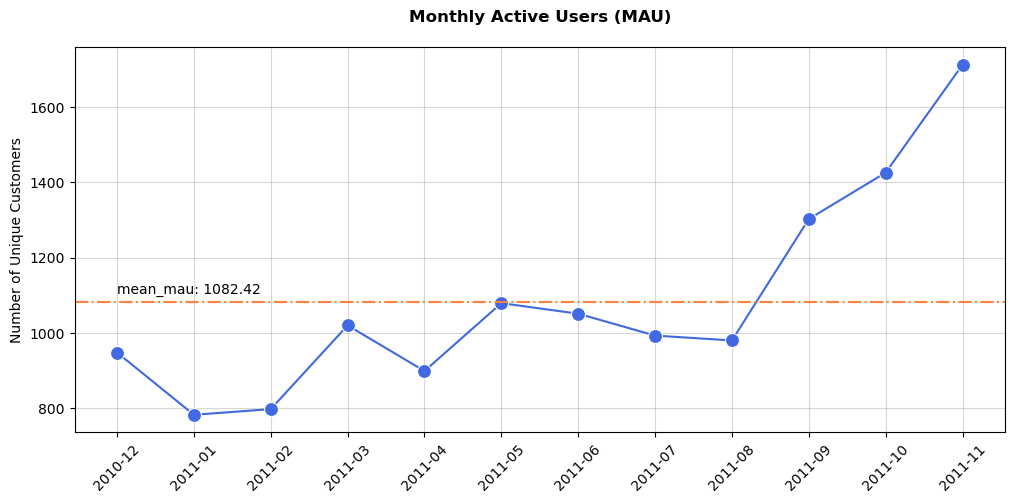

In [106]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data= mau,
    x= 'year_month',
    y= 'cust_id',
    marker= 'o',
    markersize= 10,
    color= 'royalblue'
)
plt.title('Monthly Active Users (MAU)\n', fontweight= 'bold')
plt.xlabel('')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation = 45)
plt.grid(True, alpha= 0.5)
plt.axhline(y = mean_mau, ls='-.', color='#FF7F3E')
plt.text(x = 0, y = mean_mau*1.02, s=f'mean_mau: {round(mean_mau, 2)}')
plt.show()

#### Phân tích biểu đồ Monthly Active Users
    Giai đoạn đầu suy giảm nhẹ (2010-12 -> 2011-02)
Từ khoảng 950 giảm còn 800 users
Giảm khoảng 20% so với đầu 2010-12 
Do sau Giáng sinh và New year nên thị trường tạm thời bão hòa

    Giai đoạn phục hồi và tăng trưởng chậm (2011-03 -> 2011-08)
Từ 800 users tăng trưởng lên 1020 users vào tháng 3 rồi dao động quanh 1100 ở tháng 5,6 có lúc giảm nhẹ vào tháng 4,7,8.
Tăng trưởng không đều nhưng đang tích lũy 
Đây là giai đoạn ổn định cho thấy đang mở rộng thị trường một cách chậm rãi 

    Giai đoạn tăng tốc mạnh (2011-09 -> 2011-11)
Từ 1000 users ở tháng 8 tăng trưởng lên 1700 users trong tháng 11
Tăng trưởng 70% trong vòng 3 tháng

    Từ giai đoạn 2011-08 lan tỏa số lượng người dùng mạnh mẽ sau khoảng thời gian dài tích lũy


### 4.2 Number of orders & Total order amount each month

In [107]:
# Number of orders & Total order amount each month
month_order = df.groupby('year_month').agg(
    numbers_order = ('invoice_num', 'nunique'),
    total_amount = ('Amount', 'sum')
).reset_index()
month_order

,year_month,numbers_order,total_amount
0,2010-12,1708,590823.760
1,2011-01,1236,663815.700
2,2011-02,1202,457728.550
3,2011-03,1619,611036.910
4,2011-04,1384,512352.871
5,2011-05,1849,708938.040
6,2011-06,1707,714414.220
7,2011-07,1593,625943.541
8,2011-08,1544,674319.800
9,2011-09,2078,974236.392


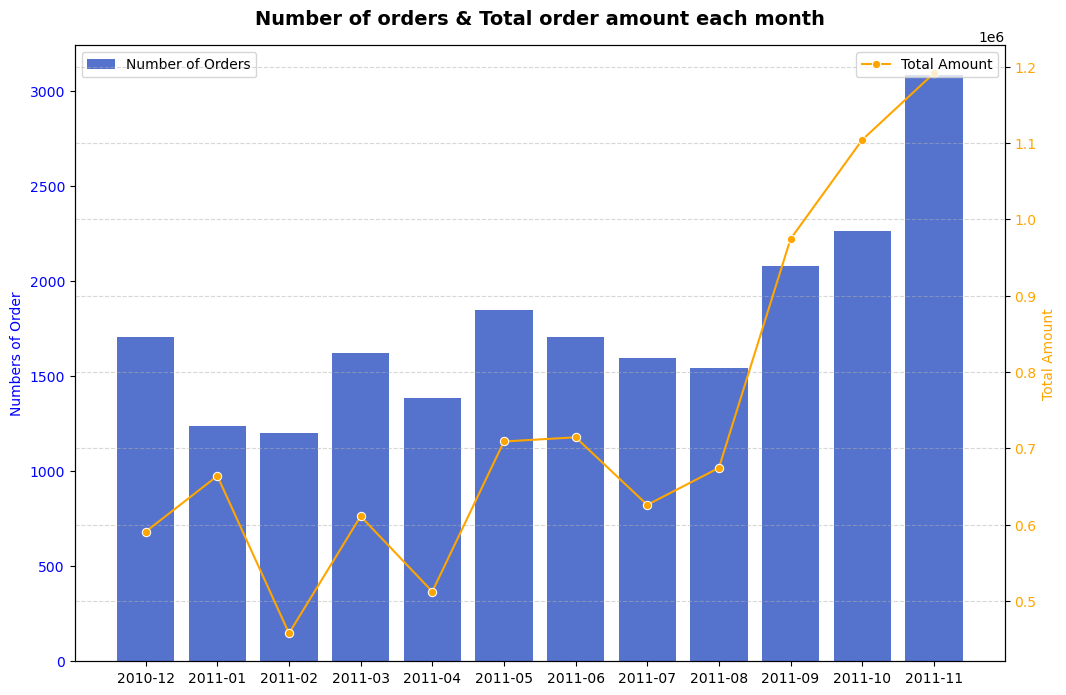

In [108]:
plt.figure(figsize=(12,8))
ax = sns.barplot(
    data= month_order,
    x= 'year_month',
    y= 'numbers_order',
    color='royalblue',
    label='Number of Orders'
)
plt.ylabel('Numbers of Order',
           color= 'blue')
plt.yticks(color= 'blue')
plt.xlabel('')
plt.twinx()

sns.lineplot(
    data= month_order,
    x= 'year_month',
    y= 'total_amount',
    marker = 'o',
    color= 'orange',
    label='Total Amount'
)
plt.ylabel('Total Amount',
           color= 'orange')
plt.yticks(color= 'orange')
plt.title('Number of orders & Total order amount each month',
          fontsize=14,
          pad= 15,
          fontweight= 'bold')
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.show()

#### Phân tích Number of orders & Total order amount each month
    Số lượng đơn hàng
Bắt đầu từ 1700 đơn hàng (12-2010) giảm xuống còn khoảng 1200 đơn hàng ở 2 tháng đầu năm 2011 sau đó dao động quanh 1500-1800 đơn hàng từ 2011-03 -> 2011-08
Bùng nổ từ 2011-09 -> 2011-11 lên đến 3000 đơn hàng
Tăng trưởng khoảng 76% trong 3 tháng cuối năm

    Tổng giá trị đơn hàng
Bắt đầu từ khoảng 0.6 triệu (2010-12) giảm mạnh xuống còn khoảng 0.45 triệu (2011-02)
Dao động nữa đầu năm khoảng 0.6-0.7 triệu
Tăng mạnh vào 2011-09 0.97 triệu đến 2011-11 là 1.19 triệu
Tăng trưởng 100% từ 0.6tr lên 1.12tr vào nửa cuối năm 2011

### 4.3 Analyze the number of customers by weekdays and by hour

In [109]:
# Analyze the number of customers by weekdays and by hour
df.head(3)

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00


In [110]:
weekday_customer =  df.groupby('week_days')['cust_id'].nunique().reset_index()
weekday_customer

,week_days,cust_id
0,Fri,1635
1,Mon,1721
2,Sun,1225
3,Thu,2119
4,Tue,1805
5,Wed,1890


In [111]:
hour_customer = df.groupby('hour')['cust_id'].nunique().reset_index()
hour_customer

,hour,cust_id
0,6,21
1,7,30
2,8,432
3,9,973
4,10,1365
5,11,1406
6,12,1685
7,13,1641
8,14,1470
9,15,1377


In [112]:
weekday_customer = weekday_customer.set_index('week_days').loc[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sun']].reset_index()
weekday_customer

,week_days,cust_id
0,Mon,1721
1,Tue,1805
2,Wed,1890
3,Thu,2119
4,Fri,1635
5,Sun,1225


C:\Users\Admin\AppData\Local\Temp\ipykernel_22700\1391966243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data= weekday_customer,
C:\Users\Admin\AppData\Local\Temp\ipykernel_22700\1391966243.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=hour_customer,


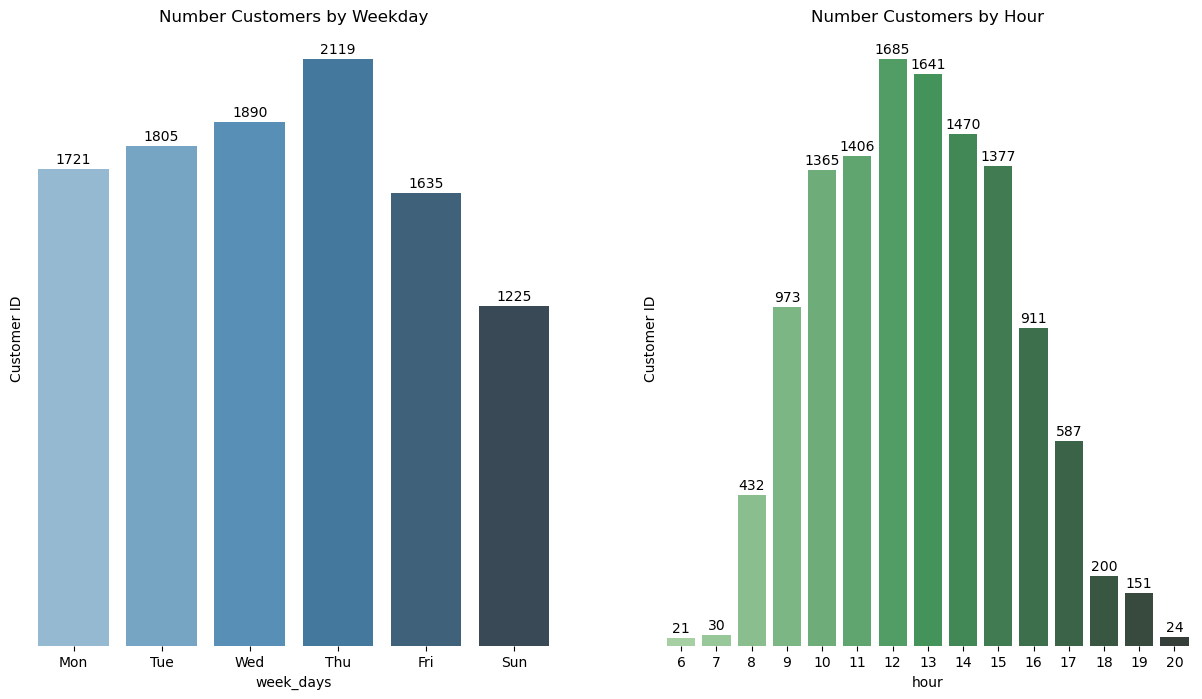

In [113]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
ax = sns.barplot(data= weekday_customer,
            x= 'week_days',
            y= 'cust_id',
            palette= 'Blues_d')
for cont in ax.containers:
    plt.bar_label(cont, padding=2)
plt.ylabel('Customer ID')
plt.yticks([])
ax.set_frame_on(False)
plt.title('Number Customers by Weekday')

plt.subplot(1,2,2)
ax2 = sns.barplot(data=hour_customer,
            x= 'hour',
            y= 'cust_id',
            palette= 'Greens_d')
for cont in ax2.containers:
    plt.bar_label(cont, padding=2)
plt.ylabel('Customer ID')
plt.yticks([])
ax2.set_frame_on(False)
plt.title('Number Customers by Hour')
plt.show()

In [114]:
dfplot1 = pd.pivot_table(
    data=df,
    index='week_days',
    columns= 'hour',
    values= 'cust_id',
    aggfunc= 'nunique'
).loc[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sun']]
dfplot1

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
week_days,,,,,,,,,,,,,,,
Mon,NaN,4.0,78.0,225.0,286.0,315.0,407.0,402.0,338.0,293.0,195.0,103.0,10.0,NaN,NaN
Tue,NaN,5.0,107.0,266.0,355.0,375.0,444.0,402.0,331.0,334.0,185.0,130.0,3.0,NaN,NaN
Wed,NaN,4.0,98.0,286.0,363.0,351.0,467.0,414.0,362.0,353.0,256.0,98.0,NaN,1.0,1.0
Thu,21.0,9.0,90.0,263.0,397.0,347.0,459.0,412.0,400.0,373.0,288.0,266.0,188.0,151.0,22.0
Fri,NaN,8.0,112.0,250.0,350.0,307.0,379.0,347.0,297.0,252.0,127.0,84.0,3.0,1.0,1.0
Sun,NaN,NaN,NaN,5.0,170.0,300.0,350.0,290.0,252.0,259.0,89.0,NaN,NaN,NaN,NaN


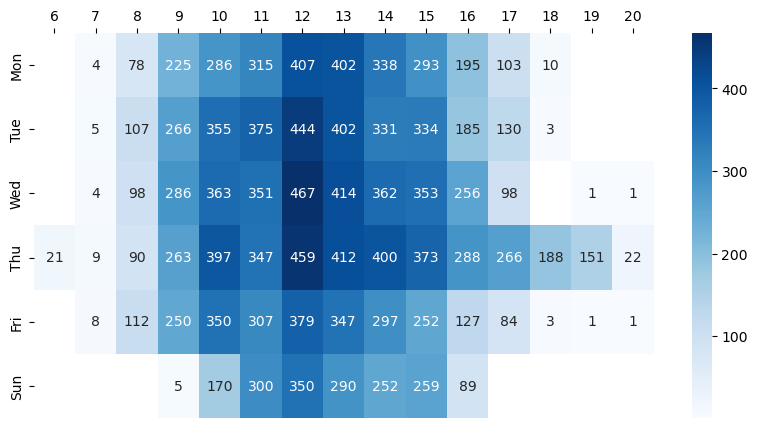

In [115]:
plt.figure(figsize=(10,5))
ax6 =sns.heatmap(data=dfplot1,
            annot= True,
            fmt='.0f',
            cmap= 'Blues')
plt.ylabel('')
plt.xlabel('')
ax6.xaxis.tick_top()
plt.show()

#### Phân tích lượng khách hàng trong tuần và theo giờ
    Phân bố khách hàng trong tuần
Tăng trưởng mạng trong tuần và giảm dần về cuối tuần
Khách hàng hoạt động mạnh ở giữa tuần (thứ tư và thứ năm) giảm dần về cuối tuần thấp nhất là chủ nhật

    Phân bố khách hàng theo giờ
Giờ cao điểm vào lúc trưa đến đầu giờ chiều 
    
    Cơ hội tối ưu khách hàng
Tập trung marketing vào lúc 11-14h ngày thứ ba đến thứ năm hàng tuần 
Khuyến mãi giờ trưa


### 4.4 Top 10 country most sales

In [116]:
# Top 10 country most sales
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34


In [117]:
top_10_country = df.groupby('country')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_country

,country,Amount
0,United Kingdom,7202061.844
1,Netherlands,274503.120
2,EIRE,273825.110
3,Germany,227872.430
4,France,213830.250
5,Australia,139965.350
6,Spain,68018.650
7,Switzerland,57148.500
8,Belgium,40055.690
9,Sweden,39684.750


C:\Users\Admin\AppData\Local\Temp\ipykernel_22700\3710249585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data= top_10_country,


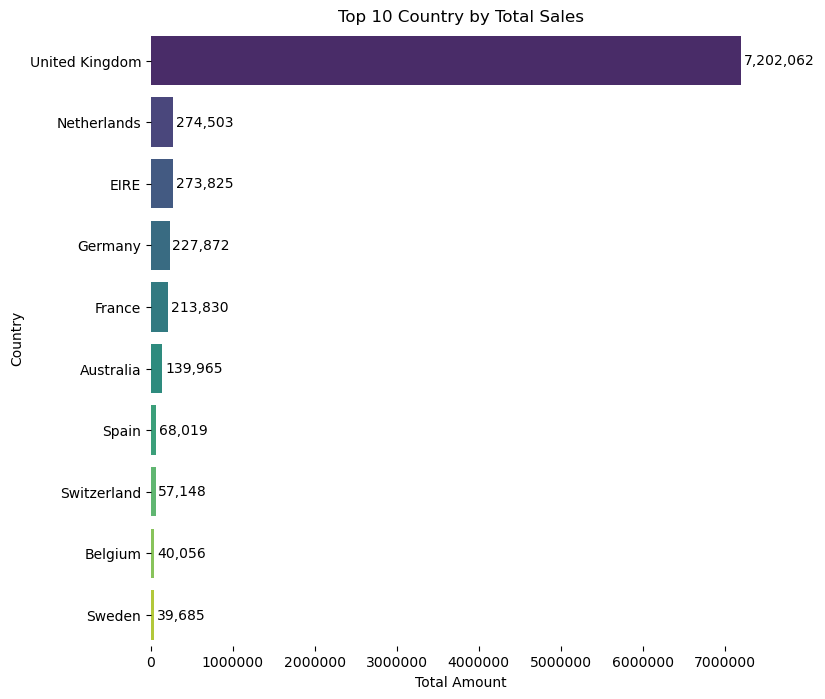

In [118]:
plt.figure(figsize=(8,8))
ax3 = sns.barplot(data= top_10_country,
            x= 'Amount',
            y= 'country',
            palette='viridis')
for cont in ax3.containers:
    plt.bar_label(cont,fmt='{:,.0f}', padding=2)
plt.title('Top 10 Country by Total Sales')
plt.xlabel('Total Amount')
plt.ticklabel_format(style='plain', axis='x')
plt.ylabel('Country')
ax3.set_frame_on(False)
plt.show()

#### Phân tích Top 10 quốc gia theo tổng doanh số bán hàng
    Thị trường UK chiếm gần như toàn bộ doanh số bán hàng
    Phụ thuộc quá nhiều vào thị trường UK, cần đẩy mạnh thị trường EU
    Đẩy mạnh marketing thị trường Netherlands, EIRE, Germany 

### 4.5 Countries with most AOV - Average Order Value

In [119]:
# Countries with most AOV - Average Order Value
country_order = df.groupby('country').agg(numbers_order = ('invoice_num', 'nunique'),
                          total_amount = ('Amount', 'sum')).reset_index()
country_order

,country,numbers_order,total_amount
0,Australia,69,139965.350
1,Austria,18,9559.840
2,Bahrain,2,548.400
3,Belgium,114,40055.690
4,Brazil,1,1143.600
5,Canada,6,3666.380
6,Channel Islands,31,20611.940
7,Cyprus,19,14143.220
8,Czech Republic,5,945.760
9,Denmark,20,18973.640


In [120]:
country_order['AOV']= country_order['total_amount'] / country_order['numbers_order']
country_order

,country,numbers_order,total_amount,AOV
0,Australia,69,139965.350,2028.483333
1,Austria,18,9559.840,531.102222
2,Bahrain,2,548.400,274.200000
3,Belgium,114,40055.690,351.365702
4,Brazil,1,1143.600,1143.600000
5,Canada,6,3666.380,611.063333
6,Channel Islands,31,20611.940,664.901290
7,Cyprus,19,14143.220,744.380000
8,Czech Republic,5,945.760,189.152000
9,Denmark,20,18973.640,948.682000


In [121]:
country_order = country_order.sort_values('AOV',ascending= False).head(10)
country_order

,country,numbers_order,total_amount,AOV
29,Singapore,10,33438.19,3343.819000
23,Netherlands,98,274503.12,2801.052245
0,Australia,69,139965.35,2028.483333
20,Lebanon,1,1693.88,1693.880000
19,Japan,27,39375.19,1458.340370
17,Israel,6,7449.13,1241.521667
4,Brazil,1,1143.60,1143.600000
33,USA,4,4274.66,1068.665000
27,RSA,1,1002.31,1002.310000
9,Denmark,20,18973.64,948.682000


C:\Users\Admin\AppData\Local\Temp\ipykernel_22700\1344190143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=country_order,


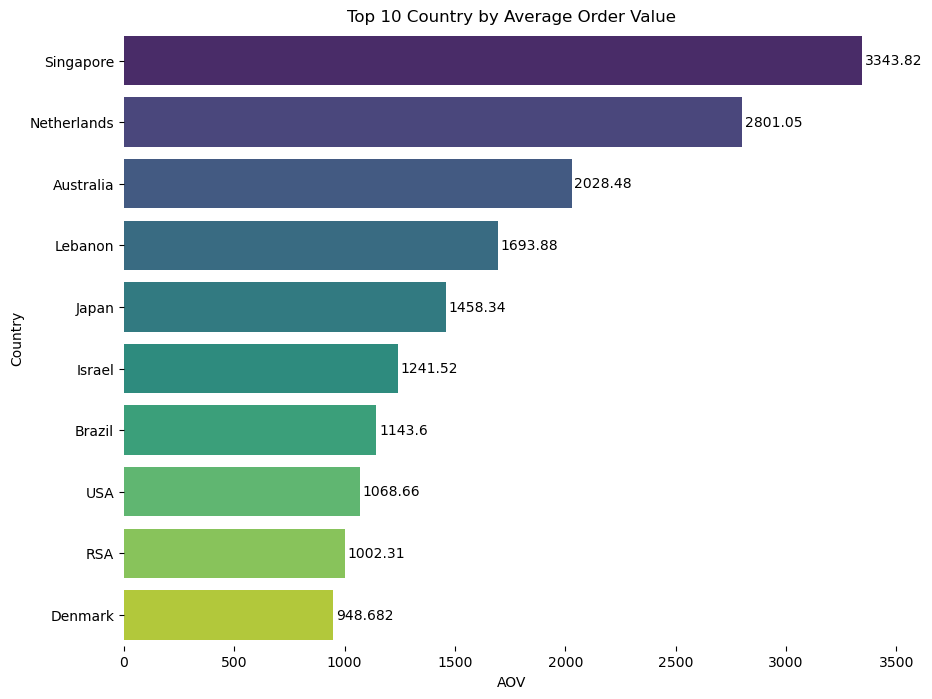

In [122]:
plt.figure(figsize=(10,8))
ax4 = sns.barplot(data=country_order,
            x='AOV',
            y= 'country',
            palette='viridis')
for cont in ax4.containers:
    plt.bar_label(cont, padding=2)
ax4.set_frame_on(False)
plt.ylabel('Country')
plt.title('Top 10 Country by Average Order Value')
plt.show()


#### Top 10 quốc gia có giá trị trung bình mỗi đơn hàng cao
    AOV ở Singapore cực cao cho thấy đơn hàng từ Singapore giá trị lớn 
    UK doanh thu cao nhưng AOV thấp -> nhiều đơn hàng nhỏ lẻ lặp lại (retail)
    Singapore không nằm trong top doanh thu nhưng AOV cao -> khách hàng mua sỉ nhiều (bulk buyer, wholesale)
    
    Top AOV là các nước không phải EU -> công ty có khách hàng quốc tế cao cấp, sẵn sàng chi trả phí ship cao cho sản phẩm. Đây là dấu hiệu tốt vì nếu chi phí sản xuất thấp, phí ship cao vẫn có lợi nhuận lớn đến từ Singapore và Netherlands

    Tập trung upsell/cross sell cho khách hàng ở Singapore, Netherlands, Australia
    Marketing nhắm tới wholesaler ở các nước này 
    Giảm phí ship cho các nước AOV lớn. Rủi ro tiềm tàng là phụ thuộc big orders từ ít khách thì nếu mất 1 khách là mất nhiều doanh thu


### 4.5 New and Old customers

In [123]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34


In [124]:
first_purchase = (
    df.groupby('cust_id')['year_month'].min().reset_index())
first_purchase

,cust_id,year_month
0,12346.0,2011-01
1,12347.0,2010-12
2,12348.0,2010-12
3,12349.0,2011-11
4,12350.0,2011-02
...,...,...
4326,18280.0,2011-03
4327,18281.0,2011-06
4328,18282.0,2011-08
4329,18283.0,2011-01


In [125]:
new_customers = first_purchase.groupby('year_month')['cust_id'].nunique().reset_index(name= 'new_customers')
new_customers

,year_month,new_customers
0,2010-12,948
1,2011-01,421
2,2011-02,380
3,2011-03,440
4,2011-04,299
5,2011-05,279
6,2011-06,235
7,2011-07,191
8,2011-08,167
9,2011-09,298


In [126]:
total_customers = df.groupby('year_month')['cust_id'].nunique().reset_index(name= 'total_customers')
total_customers

,year_month,total_customers
0,2010-12,948
1,2011-01,783
2,2011-02,798
3,2011-03,1020
4,2011-04,899
5,2011-05,1079
6,2011-06,1051
7,2011-07,993
8,2011-08,980
9,2011-09,1302


In [127]:
result_all = total_customers.merge(new_customers, on= 'year_month', how= 'left')
result_all

,year_month,total_customers,new_customers
0,2010-12,948,948
1,2011-01,783,421
2,2011-02,798,380
3,2011-03,1020,440
4,2011-04,899,299
5,2011-05,1079,279
6,2011-06,1051,235
7,2011-07,993,191
8,2011-08,980,167
9,2011-09,1302,298


In [128]:
result_all['returning_customers'] = result_all['total_customers'] - result_all['new_customers']
result_all

,year_month,total_customers,new_customers,returning_customers
0,2010-12,948,948,0
1,2011-01,783,421,362
2,2011-02,798,380,418
3,2011-03,1020,440,580
4,2011-04,899,299,600
5,2011-05,1079,279,800
6,2011-06,1051,235,816
7,2011-07,993,191,802
8,2011-08,980,167,813
9,2011-09,1302,298,1004


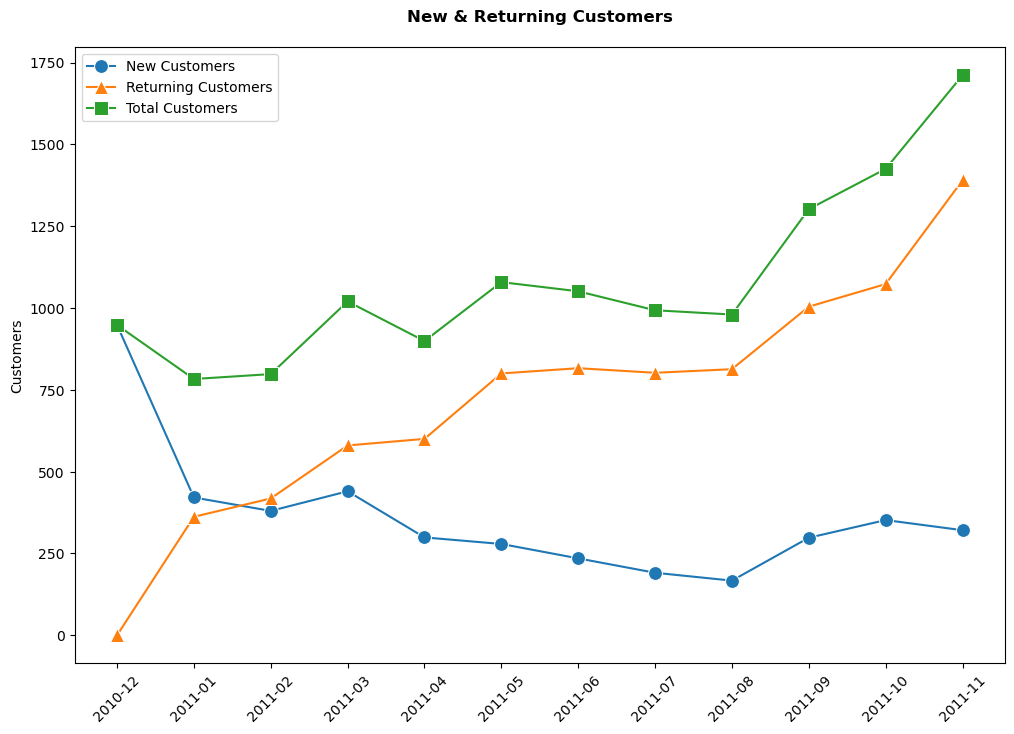

In [129]:
plt.figure(figsize=(12,8))
sns.lineplot(data= result_all,
             x= 'year_month',
             y='new_customers',
             marker= 'o',
             markersize= 10,
             label='New Customers')
sns.lineplot(data= result_all,
             x= 'year_month',
             y='returning_customers',
             marker= '^',
             markersize= 10,
             label='Returning Customers')
sns.lineplot(data= result_all,
             x= 'year_month',
             y='total_customers',
             marker= 's',
             markersize= 10,
             label='Total Customers')
plt.title('New & Returning Customers\n', fontweight= 'bold')
plt.xlabel('')
plt.ylabel('Customers')
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Phân tích khách hàng cũ và khách hàng mới
    Tỷ lệ khách hàng cũ quay trở lại tăng từ 45% (2011-01) lên đến khoảng 80% vào cuối năm 2011
    Trong toàn chu kì số lượng khách hàng cũ chiếm khoảng 60% số lượng khách hàng 
    Khách hàng mới giảm dần nhưng lượng khách hàng cũ quay lại bù đắp vào phần tăng trưởng
    Dựa vào biểu đồ trước đó thì tăng trưởng đến từ khách hàng cũ và doanh thu UK chiếm đa số. AOV cao ở Singapore, Netherlands, Australia -> khách hàng cũ quốc tế mua lớn định kì
    Thời điểm mua hàng là trong tuần và thời gian nghỉ trưa -> nhân viên đặt hàng trong giờ làm việc

### 4.6 Returning customers by december 2010

In [130]:
first_purchase = (
    df.groupby('cust_id')['year_month'].min().reset_index(name='first_year_month_purchase'))
first_purchase

,cust_id,first_year_month_purchase
0,12346.0,2011-01
1,12347.0,2010-12
2,12348.0,2010-12
3,12349.0,2011-11
4,12350.0,2011-02
...,...,...
4326,18280.0,2011-03
4327,18281.0,2011-06
4328,18282.0,2011-08
4329,18283.0,2011-01


In [131]:
df = df.merge(first_purchase, on= 'cust_id', how='left')

In [132]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount,first_year_month_purchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12


In [133]:
df['first_year_month_purchase'] = pd.to_datetime(df['first_year_month_purchase']).dt.to_period('M')

In [134]:
dec_2010 = df[df['first_year_month_purchase']== '2010-12']
dec_2010

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount,first_year_month_purchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389002,C579882,23245,SET OF 3 REGENCY CAKE TINS,1,2011-11-30 17:28:00,4.95,13050.0,United Kingdom,11,30,17,Wed,2011-11,4.95,2010-12
389005,C579884,D,Discount,1,2011-11-30 17:34:00,20.53,14527.0,United Kingdom,11,30,17,Wed,2011-11,20.53,2010-12
389165,C579887,84946,ANTIQUE SILVER T-LIGHT GLASS,1,2011-11-30 17:42:00,1.25,16717.0,United Kingdom,11,30,17,Wed,2011-11,1.25,2010-12
389166,C579887,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,1,2011-11-30 17:42:00,7.95,16717.0,United Kingdom,11,30,17,Wed,2011-11,7.95,2010-12


In [135]:
transaction_value = dec_2010.groupby(['year_month', 'invoice_num']).agg(transaction_value=('Amount', 'sum')).reset_index()
transaction_value

,year_month,invoice_num,transaction_value
0,2010-12,536365,139.12
1,2010-12,536366,22.20
2,2010-12,536367,278.73
3,2010-12,536368,70.05
4,2010-12,536369,17.85
...,...,...,...
9919,2011-11,C579869,16.30
9920,2011-11,C579878,121.84
9921,2011-11,C579882,14.85
9922,2011-11,C579884,20.53


In [136]:
total_avg = transaction_value.groupby('year_month').agg(transaction_value_average = ('transaction_value', 'mean'),
                                            total_transaction = ('invoice_num', 'nunique')).reset_index()
total_avg

,year_month,transaction_value_average,total_transaction
0,2010-12,345.915550,1708
1,2011-01,420.420087,689
2,2011-02,422.878169,579
3,2011-03,428.765299,753
4,2011-04,348.825794,611
5,2011-05,454.281910,801
6,2011-06,445.907201,736
7,2011-07,475.011939,691
8,2011-08,546.815688,661
9,2011-09,620.276967,798


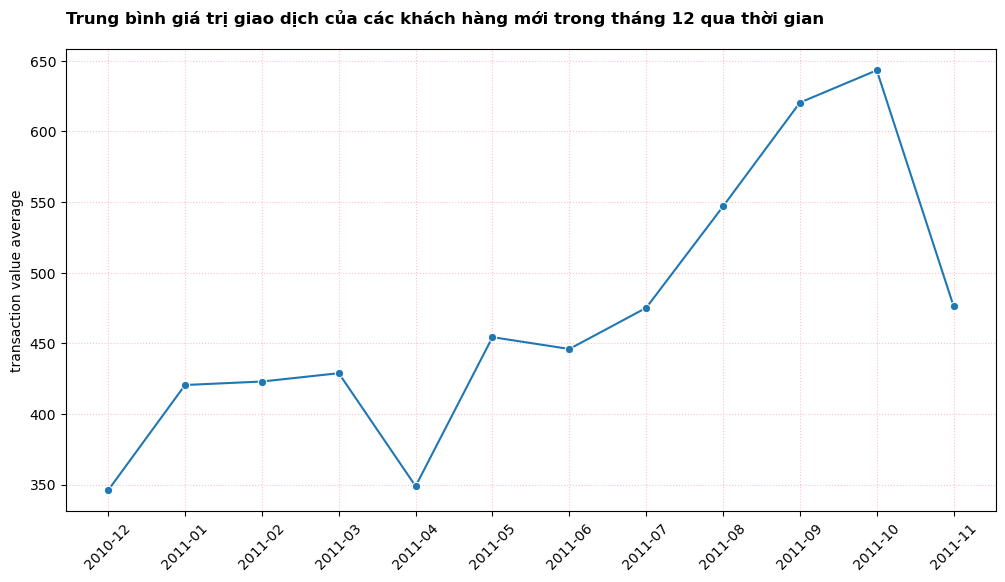

In [137]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data = total_avg,
    x = 'year_month',
    y = 'transaction_value_average',
    marker='o')
plt.xlabel('')
plt.ylabel('transaction value average')
plt.title(f'Trung bình giá trị giao dịch của các khách hàng mới trong tháng 12 qua thời gian\n', weight = 'bold', loc='left')
plt.xticks(rotation=45), plt.xlabel('')
plt.grid(True, ls = ':', color = 'pink')
plt.show()

#### Phân tích khách hàng quay trở lại vào tháng 12-2010
    Số lượng khách hàng quay trở lại vào tháng 12-2010 là khoảng 400 khách hàng
    Tăng trưởng mạnh mẽ từ tháng 8-2011 đến tháng 11-2011 lên đến khoảng 1200 khách hàng quay trở lại
    Tăng trưởng khoảng 200% trong vòng 3 tháng cuối năm
    Đây là dấu hiệu rất tích cực cho thấy khách hàng quay trở lại nhiều hơn, có thể do chiến dịch marketing hiệu quả hoặc cải thiện sản phẩm/dịch vụ khiến khách hàng hài lòng và quay lại mua hàng.

### 4.7 Customer segmentation RFM

In [138]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,month,day,hour,week_days,year_month,Amount,first_year_month_purchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,1,8,Wed,2010-12,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,1,8,Wed,2010-12,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,1,8,Wed,2010-12,20.34,2010-12


In [139]:
current_date = df['invoice_date'].max()
current_date

Timestamp('2011-11-30 17:42:00')

In [144]:
regency_frequency = df.groupby('cust_id').agg(last_purchase = ('invoice_date', 'max'),
                          frequency = ('invoice_num', 'nunique'),
                          total_amount = ('Amount', 'sum')).reset_index()
regency_frequency

,cust_id,last_purchase,frequency,total_amount
0,12346.0,2011-01-18 10:17:00,2,154367.20
1,12347.0,2011-10-31 12:25:00,6,4085.18
2,12348.0,2011-09-25 13:13:00,4,1797.24
3,12349.0,2011-11-21 09:51:00,1,1757.55
4,12350.0,2011-02-02 16:01:00,1,334.40
...,...,...,...,...
4326,18280.0,2011-03-07 09:52:00,1,180.60
4327,18281.0,2011-06-12 10:53:00,1,80.82
4328,18282.0,2011-08-09 15:10:00,2,101.66
4329,18283.0,2011-11-30 12:59:00,15,1886.88


In [145]:
regency_frequency['regency'] = (current_date - regency_frequency['last_purchase']).dt.days
regency_frequency

,cust_id,last_purchase,frequency,total_amount,regency
0,12346.0,2011-01-18 10:17:00,2,154367.20,316
1,12347.0,2011-10-31 12:25:00,6,4085.18,30
2,12348.0,2011-09-25 13:13:00,4,1797.24,66
3,12349.0,2011-11-21 09:51:00,1,1757.55,9
4,12350.0,2011-02-02 16:01:00,1,334.40,301
...,...,...,...,...,...
4326,18280.0,2011-03-07 09:52:00,1,180.60,268
4327,18281.0,2011-06-12 10:53:00,1,80.82,171
4328,18282.0,2011-08-09 15:10:00,2,101.66,113
4329,18283.0,2011-11-30 12:59:00,15,1886.88,0


In [159]:
regency_frequency.describe()

,last_purchase,frequency,total_amount,regency,regency_score,frequency_score
count,4331,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000
mean,2011-09-01 06:32:32.930039296,4.910875,2038.529391,90.252828,1.754329,1.925883
min,2010-12-01 09:53:00,1.000000,0.000000,0.000000,1.000000,1.000000
25%,2011-07-09 14:21:30,1.000000,305.580000,15.000000,1.000000,1.000000
50%,2011-10-13 14:47:00,3.000000,659.610000,48.000000,2.000000,2.000000
75%,2011-11-15 15:28:00,5.000000,1626.945000,144.000000,2.000000,2.000000
max,2011-11-30 17:42:00,238.000000,269195.000000,364.000000,3.000000,3.000000
std,NaN,9.025901,8943.298239,99.388939,0.825210,0.739391


Nhìn vào kết quả của hàm describe phía trên, ta chọn các mốc phân chia điểm cho 2 chỉ số như sau:
+ Recency:
    + 1đ: >48 ngày ngủ đông (chiếm ~50% tổng lượng khách hàng)
    + 2đ: 15-48 (15 <= x <= 48) ngày ngủ đông (chiếm ~25% tổng lượng khách hàng)
    + 3đ: <15 ngày ngủ đông (chiếm ~25% tổng lượng khách hàng)

+ Frequency:
    + 1đ: 1 giao dịch (chiếm ~25% tổng lượng khách hàng)
    + 2đ: 2-5 giao dịch (chiếm ~50% tổng lượng khách hàng)
    + 3đ: >5 giao dịch (chiếm ~25% tổng lượng khách hàng)

In [160]:
regency_frequency['monetary_score'] = pd.qcut(
    regency_frequency['total_amount'],
    3,
    labels=[1,2,3]
)

In [161]:
def regency_score(x):
    if x> 48:
        return 1
    elif x >= 15:
        return 2
    else:
        return 3

In [162]:
def frequency_score(x):
    if x == 1:
        return 1
    elif (x>=2) and (x<=5):
        return 2
    else:
        return 3

In [163]:
regency_frequency['regency_score'] = regency_frequency['regency'].apply(regency_score)
regency_frequency['frequency_score'] = regency_frequency['frequency'].apply(frequency_score)

In [164]:
def customer_segmentation(r):
    if r['regency_score']==3 and r['frequency_score']>=2 and r['monetary_score']==3:
        return 'VIP'
    elif r['regency_score']==3 and r['frequency_score']>=2:
        return 'Loyal'
    elif r['regency_score']==3:
        return 'New Customer'
    elif r['regency_score']==2 and r['monetary_score']==3:
        return 'High Value At Risk'
    elif r['regency_score']==1 and r['monetary_score']==3:
        return 'Lost VIP'
    else:
        return 'Others'

In [165]:
regency_frequency['customer_segmentation'] = regency_frequency.apply(customer_segmentation, axis=1)
regency_frequency

,cust_id,last_purchase,frequency,total_amount,regency,monetary_score,regency_score,frequency_score,customer_segmentation
0,12346.0,2011-01-18 10:17:00,2,154367.20,316,3,1,2,Lost VIP
1,12347.0,2011-10-31 12:25:00,6,4085.18,30,3,2,3,High Value At Risk
2,12348.0,2011-09-25 13:13:00,4,1797.24,66,3,1,2,Lost VIP
3,12349.0,2011-11-21 09:51:00,1,1757.55,9,3,3,1,New Customer
4,12350.0,2011-02-02 16:01:00,1,334.40,301,1,1,1,Others
...,...,...,...,...,...,...,...,...,...
4326,18280.0,2011-03-07 09:52:00,1,180.60,268,1,1,1,Others
4327,18281.0,2011-06-12 10:53:00,1,80.82,171,1,1,1,Others
4328,18282.0,2011-08-09 15:10:00,2,101.66,113,1,1,2,Others
4329,18283.0,2011-11-30 12:59:00,15,1886.88,0,3,3,3,VIP


In [166]:
segment_count = regency_frequency['customer_segmentation'].value_counts().reset_index()
segment_count

,customer_segmentation,count
0,Others,2425
1,VIP,609
2,High Value At Risk,462
3,Lost VIP,371
4,Loyal,349
5,New Customer,115


In [167]:
segment_revenue = regency_frequency.groupby('customer_segmentation')['total_amount'].sum().reset_index()
segment_revenue

,customer_segmentation,total_amount
0,High Value At Risk,1964626.130
1,Lost VIP,1183125.141
2,Loyal,229412.870
3,New Customer,34022.270
4,Others,1065917.603
5,VIP,4351766.780


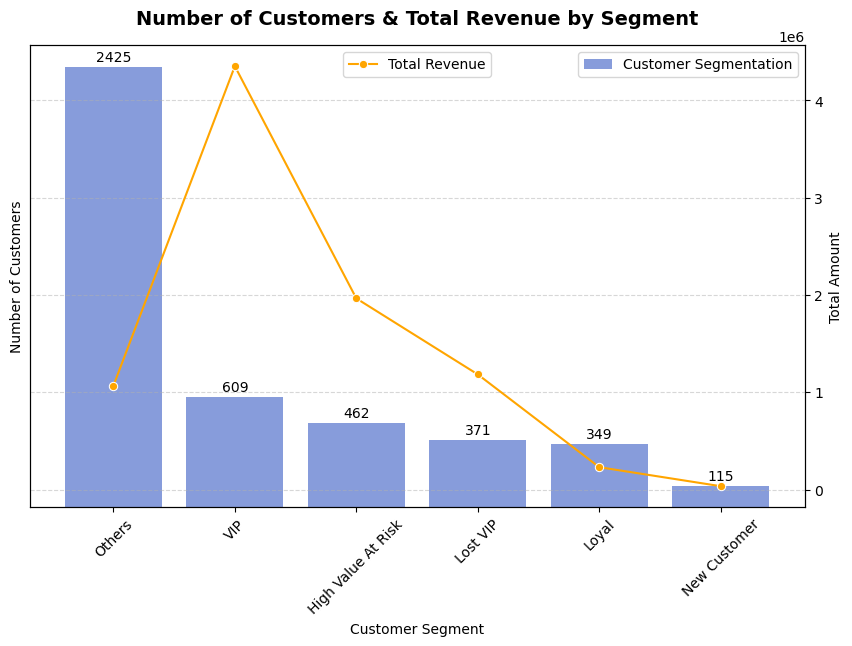

In [168]:
plt.figure(figsize=(10,6))
ax5 = sns.barplot(
    data=segment_count,
    x='customer_segmentation',
    y='count',
    color='royalblue',
    alpha=0.7,
    label='Customer Segmentation'
)
for cont in ax5.containers:
    plt.bar_label(cont, padding=2)
plt.yticks([])
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(loc=0, fontsize=10)
plt.twinx()

sns.lineplot(
    data= segment_revenue,
    x='customer_segmentation',
    y= 'total_amount',
    marker = 'o',
    color= 'orange',
    label='Total Revenue'
)
plt.ylabel('Total Amount')
plt.title('Number of Customers & Total Revenue by Segment',
          fontsize=14,
          pad= 15,
          fontweight= 'bold')
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.legend(loc=9, fontsize=10)

plt.show()

### Phân loại khách hàng và tổng doanh thu 
Nhóm Loyal có số lượng khách hàng ít nhưng đóng góp ổn định (dù tỷ lệ % doanh thu không cao bằng các nhóm lớn trước đây).

Nhóm High Value At Risk và Lost VIP là hai nhóm có giá trị doanh thu rất lớn (tổng cộng hơn 35.7% doanh thu). Đây là những khách hàng từng có giá trị cao nhưng đang có nguy 
cơ mất hoặc đã mất.

Nhóm Others cũng chiếm tỷ lệ đáng kể (12.1%), cần đánh giá thêm xem có tiềm năng chuyển đổi không.

New Customer chiếm tỷ lệ doanh thu rất nhỏ, phù hợp với đặc thù khách hàng mới.

    Rủi ro lớn:
Nhóm High Value At Risk + Lost VIP + Others hiện đang chiếm khoảng 48% tổng doanh thu. Nếu không có hành động kịp thời, doanh thu có thể giảm mạnh trong 3-6 tháng tới, đặc biệt là từ nhóm High Value At Risk (đang ở trạng thái “nguy cơ cao”).

    Cơ hội & Khuyến nghị:

 Ưu tiên hàng đầu: High Value At Risk
* Chương trình khẩn cấp: ưu đãi mạnh (freeship, giảm giá sâu, voucher đặc biệt), survey lý do giảm giao dịch, chăm sóc cá nhân hóa.

Lost VIP
* Chiến dịch win-back: ưu đãi đặc biệt quay lại, quà tặng cao cấp, liên hệ trực tiếp (nếu có dữ liệu).

Loyal
* Giữ chân & phát triển: chương trình VIP, early access sản phẩm mới, tặng quà cảm ơn, tích điểm cao hơn.

Others
* Phân tích sâu hơn để xem có thể chuyển một phần sang nhóm Loyal hoặc High Value không.

New Customer
* Tập trung nuôi dưỡng để chuyển đổi thành Loyal trong tương lai (email series, ưu đãi lần mua thứ 2, thứ 3…).
